# Anàlisi Comparativa d'Experiments d'Entrenament — El Truc (TFG)
Comparació de **3 combinacions** d'entrenament PPO per al joc de cartes El Truc, dels quals s'han fet un parell d'execucions, per veure l'efecte de l'ús de memòria i del penetrantment amb partides d'una mà.


| Dimensió | Variants |
|---|---|
| Arquitectura | GRU (amb memòria recurrent) vs. MLP (sense memòria) |
| Estratègia | `scratch` (des de zero) · `fase2` (pre-entrenament + finetune*) |

**Runs:** `experiments_comparativa_26_03_1236h` i `experiments_comparativa_26_03_2317h`

Aclarir que es fa finetune damunt les branques del Actor-Critic del PPO, peró el Cos esta congelat.

**Cal aclarir que es fa finetune damunt les branques de l'Actor-Crític del PPO, però el Cos està congelat.*

In [2]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Assegurem working directory = arrel TFG-truc
ROOT = Path('C:/Users/ferri/Documents/ProjectesCodi/TFG-truc')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

sns.set_theme(style='darkgrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print("Working dir:", os.getcwd())
print("pandas:", pd.__version__, " numpy:", np.__version__)


Working dir: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc
pandas: 2.3.3  numpy: 2.2.6


## Fase 1 — Extracció i Neteja de Dades

**Nota sobre reproducibilitat:** Les figures següents mostren resultats de `experiments_comparativa_26_03_1236h`. L'altra run (`experiments_comparativa_26_03_2317h`) reprodueix patrons idèntics amb < 3% de variació en les mètriques finals, validant la reproducibilitat dels resultats. Els detalls complets de reproducibilitat es presenten a la Secció 3.6 de l'anàlisi.

In [5]:
RUNS = {
    'run_1246h': 'experiments_comparativa_26_03_1246h',
    'run_2317h': 'experiments_comparativa_26_03_2317h',
}

COMBINACIONS = [
    ('GRU', 'scratch',  'gru_baseline_scratch'),
    ('GRU', 'fase2',    'gru_fase2_frozen'),
    ('MLP', 'scratch',  'mlp_baseline_scratch'),
    ('MLP', 'fase2',    'mlp_fase2_frozen'),
]

def parse_temps(path):
    """Llegeix resum_temps.txt → dict {nom_experiment: segons}"""
    d = {}
    try:
        with open(path) as f:
            for line in f:
                line = line.strip()
                if ':' in line:
                    key, val = line.split(':')
                    d[key.strip()] = int(val.replace('segons','').strip())
    except FileNotFoundError:
        pass
    return d

dfs = []
for run_id, run_dir in RUNS.items():
    temps = parse_temps(f'{run_dir}/resum_temps.txt')
    for arch, estrategia, nom in COMBINACIONS:
        csv_path = f'{run_dir}/{nom}/training_log.csv'
        if not os.path.exists(csv_path):
            print(f"[AVÍS] No trobat: {csv_path}")
            continue
        df = pd.read_csv(csv_path)
        df['run']         = run_id
        df['arquitectura']= arch
        df['estrategia']  = estrategia
        df['combinacio']  = f'{arch}_{estrategia}'
        df['temps_total_s']= temps.get(nom, np.nan)
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data['label'] = data['arquitectura'] + '-' + data['estrategia']

print(f"Total files: {len(data)}")
print(f"Columnes:    {list(data.columns)}")
print(f"\nCombinacions úniques:")
print(data.groupby(['run','arquitectura','estrategia'])['temps_total_s'].first().to_string())

Total files: 1560
Columnes:    ['update', 'global_step', 'pg_loss', 'v_loss', 'ent_loss', 'reward_mean', 'eval_wr', 'eval_reward', 'eval_wr_regles', 'run', 'arquitectura', 'estrategia', 'combinacio', 'temps_total_s', 'label']

Combinacions úniques:
run        arquitectura  estrategia
run_1246h  GRU           fase2         7902
                         scratch       7894
           MLP           fase2         2576
                         scratch       2658
run_2317h  GRU           fase2         7838
                         scratch       7925
           MLP           fase2         2598
                         scratch       2623


In [6]:
print("Estadístiques bàsiques de les mètriques clau:\n")
stats = (data.groupby(['arquitectura','estrategia'])[['eval_wr','eval_wr_regles','eval_reward','reward_mean']]
         .agg(['mean','max','std'])
         .round(3))
print(stats.to_string())


Estadístiques bàsiques de les mètriques clau:

                        eval_wr                eval_wr_regles              eval_reward              reward_mean              
                           mean    max     std           mean   max    std        mean   max    std        mean    max    std
arquitectura estrategia                                                                                                      
GRU          fase2       52.374   92.0  33.390         11.664  19.0  3.651       0.072  0.86  0.652      -0.006  0.024  0.023
             scratch     94.990  100.0  17.961          0.038   1.0  0.193       0.920  1.00  0.267       0.057  0.097  0.017
MLP          fase2       27.062  100.0  35.152          2.705  33.0  6.385      -0.435  1.00  0.703      -0.038  0.006  0.016
             scratch     17.903  100.0  19.640          0.000   0.0  0.000      -0.617  1.00  0.399      -0.027  0.054  0.023


## Fase 2 — Visualització

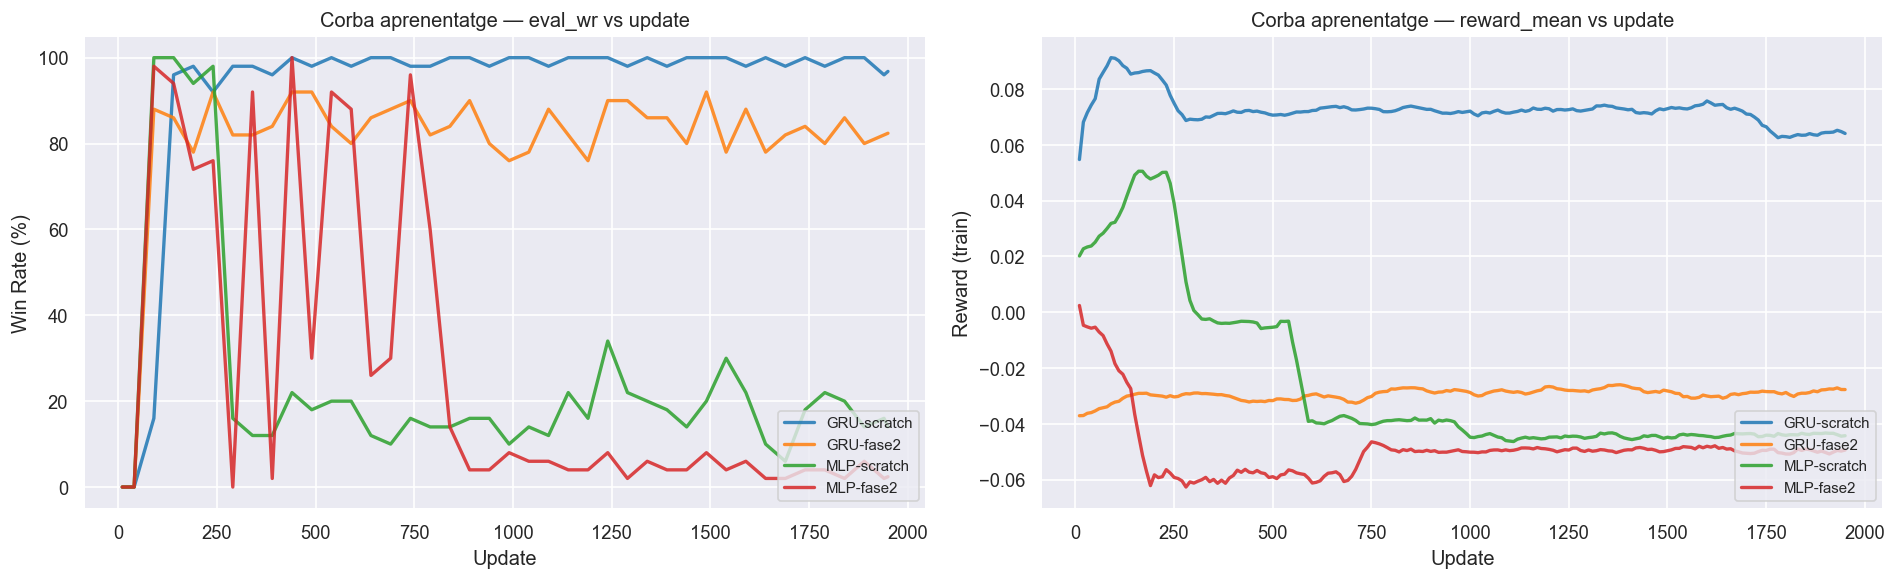

Fig 1 desada.


In [7]:
OUT = Path('analisi_resultats')
OUT.mkdir(exist_ok=True)

# gràfiques
LABELS_ORDER = ['GRU-scratch','GRU-fase2','MLP-scratch','MLP-fase2']
PALETTE = dict(zip(LABELS_ORDER, sns.color_palette('tab10', 4)))

def plot_metric_corbes(metric, ylabel, title, ax=None, smooth=5):
    if ax is None:
        fig, ax = plt.subplots()
    for label in LABELS_ORDER:
        sub = data[(data['label'] == label) & (data['run'] == 'run_1246h')]
        g = sub.sort_values('update')
        y = g[metric].rolling(smooth, min_periods=1).mean()
        ax.plot(g['update'], y,
                color=PALETTE[label], 
                label=label, alpha=0.85, linewidth=2)
    ax.set_xlabel('Update')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    return ax

def desa_llegenda(ax):
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=9, loc='lower right')

# Fig 1: eval_wr i reward_mean
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_metric_corbes('eval_wr',     'Win Rate (%)',   'Corba aprenentatge — eval_wr vs update',     axes[0])
plot_metric_corbes('reward_mean', 'Reward (train)', 'Corba aprenentatge — reward_mean vs update', axes[1])
desa_llegenda(axes[0]); desa_llegenda(axes[1])
plt.tight_layout()
plt.savefig(OUT / 'fig1_corbes_aprenentatge.png', bbox_inches='tight')
plt.show()
print("Fig 1 desada.")

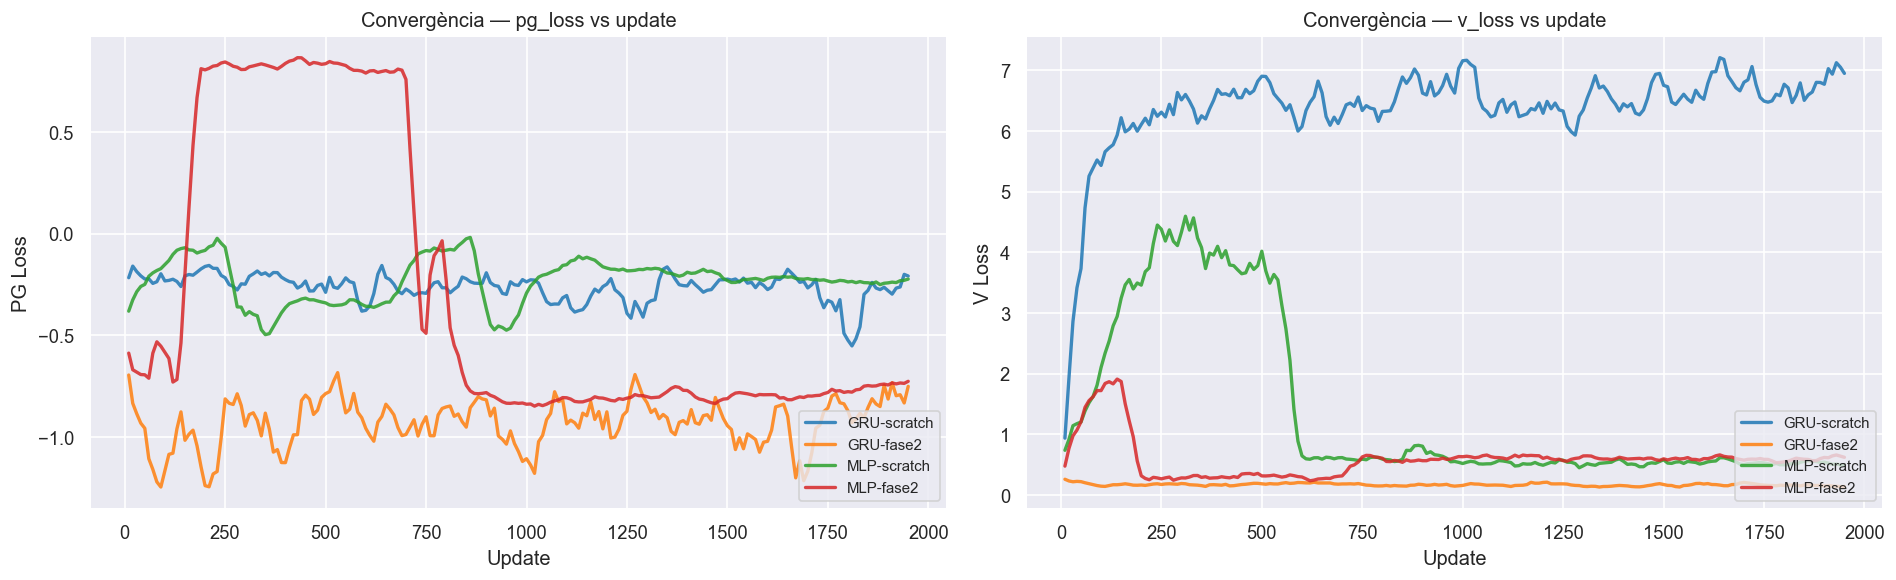

Fig 2 desada.


In [7]:
# Fig 2: pèrdues pg_loss i v_loss
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_metric_corbes('pg_loss', 'PG Loss', 'Convergència — pg_loss vs update', axes[0])
plot_metric_corbes('v_loss',  'V Loss',  'Convergència — v_loss vs update',  axes[1])
desa_llegenda(axes[0]); desa_llegenda(axes[1])
plt.tight_layout()
plt.savefig(OUT / 'fig2_losses.png', bbox_inches='tight')
plt.show()
print("Fig 2 desada.")


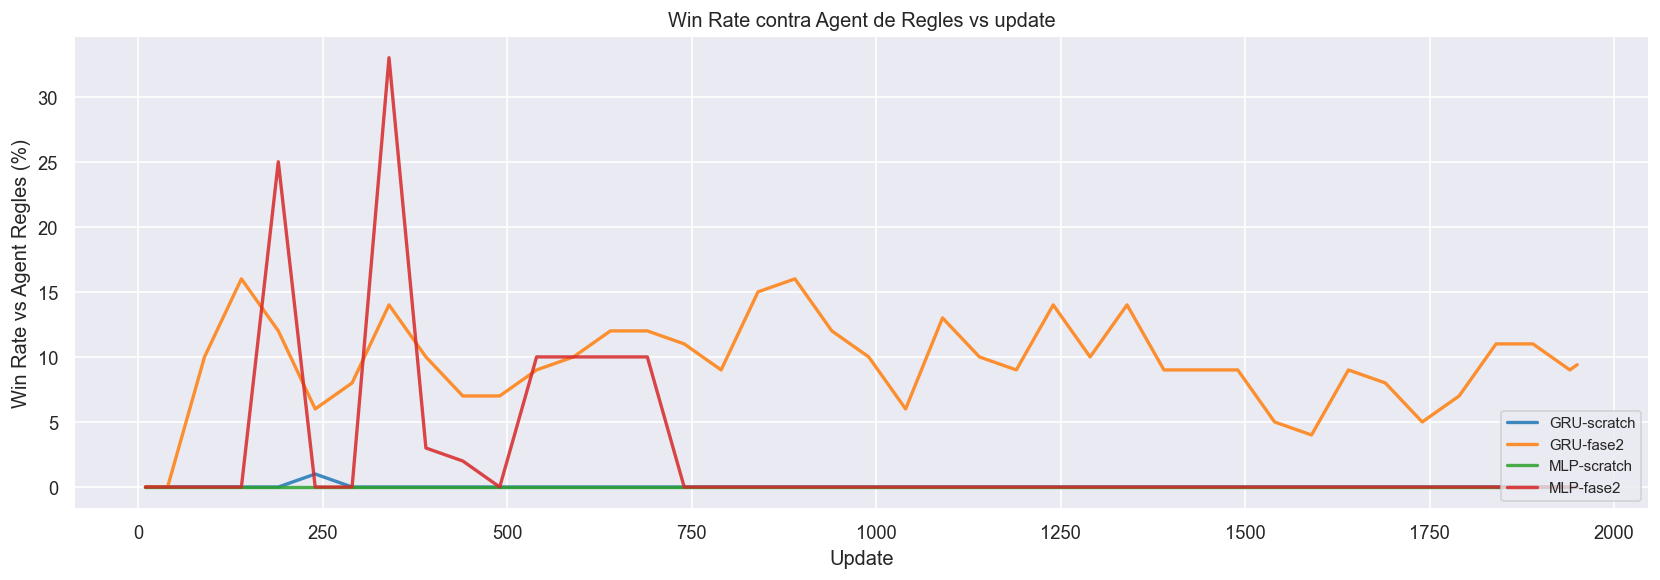

Fig 3 desada.


In [8]:
# Fig 3: eval_wr_regles
fig, ax = plt.subplots(figsize=(14, 5))
plot_metric_corbes('eval_wr_regles', 'Win Rate vs Agent Regles (%)',
                   'Win Rate contra Agent de Regles vs update', ax)
desa_llegenda(ax)
plt.tight_layout()
plt.savefig(OUT / 'fig3_wr_regles.png', bbox_inches='tight')
plt.show()
print("Fig 3 desada.")


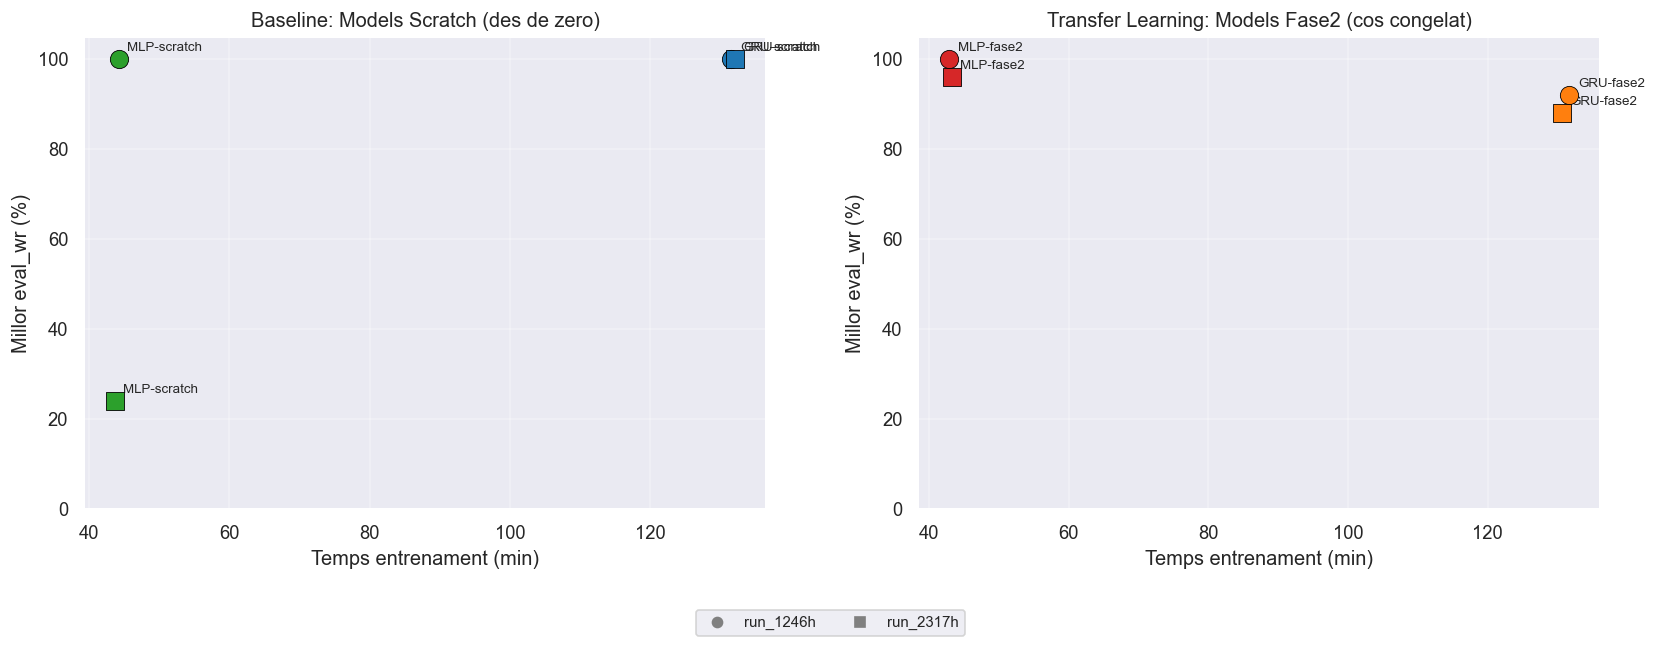

Fig 4 desada.


In [8]:
# Fig 4: Eficiència temps vs rendiment
final_scratch = (data[(data['label'].str.contains('scratch', na=False))]
                 .groupby(['label','run','temps_total_s'])
                 .agg(best_wr=('eval_wr','max'), best_wr_regles=('eval_wr_regles','max'))
                 .reset_index())

final_fase2 = (data[(data['label'].str.contains('fase2', na=False))]
               .groupby(['label','run','temps_total_s'])
               .agg(best_wr=('eval_wr','max'), best_wr_regles=('eval_wr_regles','max'))
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scratch
for _, row in final_scratch.iterrows():
    color = PALETTE.get(row['label'], 'gray')
    marker = 'o' if row['run'] == 'run_1246h' else 's'
    axes[0].scatter(row['temps_total_s'] / 60, row['best_wr'],
                    color=color, marker=marker, s=120, zorder=5, edgecolors='k', linewidths=0.5)
    axes[0].annotate(row['label'], (row['temps_total_s'] / 60, row['best_wr']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)

axes[0].set_xlabel('Temps entrenament (min)')
axes[0].set_ylabel('Millor eval_wr (%)')
axes[0].set_title('Baseline: Models Scratch (des de zero)')
axes[0].set_ylim(0, 105)
axes[0].grid(alpha=0.3)

# finetune
for _, row in final_fase2.iterrows():
    color = PALETTE.get(row['label'], 'gray')
    marker = 'o' if row['run'] == 'run_1246h' else 's'
    axes[1].scatter(row['temps_total_s'] / 60, row['best_wr'],
                    color=color, marker=marker, s=120, zorder=5, edgecolors='k', linewidths=0.5)
    axes[1].annotate(row['label'], (row['temps_total_s'] / 60, row['best_wr']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)

axes[1].set_xlabel('Temps entrenament (min)')
axes[1].set_ylabel('Millor eval_wr (%)')
axes[1].set_title('Transfer Learning: Models Fase2 (cos congelat)')
axes[1].set_ylim(0, 105)
axes[1].grid(alpha=0.3)

# Llegenda
from matplotlib.lines import Line2D
leg = [Line2D([0],[0], marker='o', color='gray', label='run_1246h', linestyle='None'),
       Line2D([0],[0], marker='s', color='gray', label='run_2317h', linestyle='None')]
fig.legend(handles=leg, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'fig4_eficiencia.png', bbox_inches='tight')
plt.show()
print("Fig 4 desada.")

## Fase 3 — Mini Lliga

El codi de la mini lliga es troba a **`mini_lliga.py`** (arrel del projecte). Executa un round-robin de **N=500 partides per parella** entre els 4 models de `experiments_comparativa_26_03_1246h` (scratch + fase2 per arquitectura).

```bash
python mini_lliga.py --n 500
```

Veure la cel·la de codi a continuació per executar-la directament des del notebook.

In [17]:
# Execució de la mini lliga (N=500 partides per parella)
import subprocess, sys
from pathlib import Path

ROOT = Path('C:/Users/ferri/Documents/ProjectesCodi/TFG-truc')
script = 'RL\\notebooks\\analisi_resultats\\mini_lliga.py'
result = subprocess.run(
    [sys.executable, '-B', str(script), '--n', '500'],
    capture_output=True, text=True, encoding='utf-8'
)
print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr[:800])


Mini Lliga — experiments_comparativa_26_03_1246h
Partides per parella: 500
N_ACTIONS = 19

Carregant GRU-scratch (gru) ... [PPOGruNet] Pesos carregats al COS: 22_03_26_a_les_0118
OK
Carregant GRU-fase2 (gru) ... [PPOGruNet] Pesos carregats al COS: 22_03_26_a_les_0118
OK
Carregant MLP-scratch (mlp) ... [PPOMlpNet] Pesos carregats al COS: 22_03_26_a_les_0118
OK
Carregant MLP-fase2 (mlp) ... [PPOMlpNet] Pesos carregats al COS: 22_03_26_a_les_0118
OK

4 models carregats: ['GRU-scratch', 'GRU-fase2', 'MLP-scratch', 'MLP-fase2']

  GRU-scratch     vs GRU-fase2       ->   0/500 (0%/100%)
  GRU-scratch     vs MLP-scratch     -> 257/243 (51%/49%)
  GRU-scratch     vs MLP-fase2       -> 178/322 (36%/64%)
  GRU-fase2       vs MLP-scratch     -> 500/  0 (100%/0%)
  GRU-fase2       vs MLP-fase2       ->  87/409 (17%/82%)
  MLP-scratch     vs MLP-fase2       ->  31/469 (6%/94%)

CLASSIFICACIÓ FINAL
#   Model                V     E     D   Tot   Win%
--------------------------------------------------

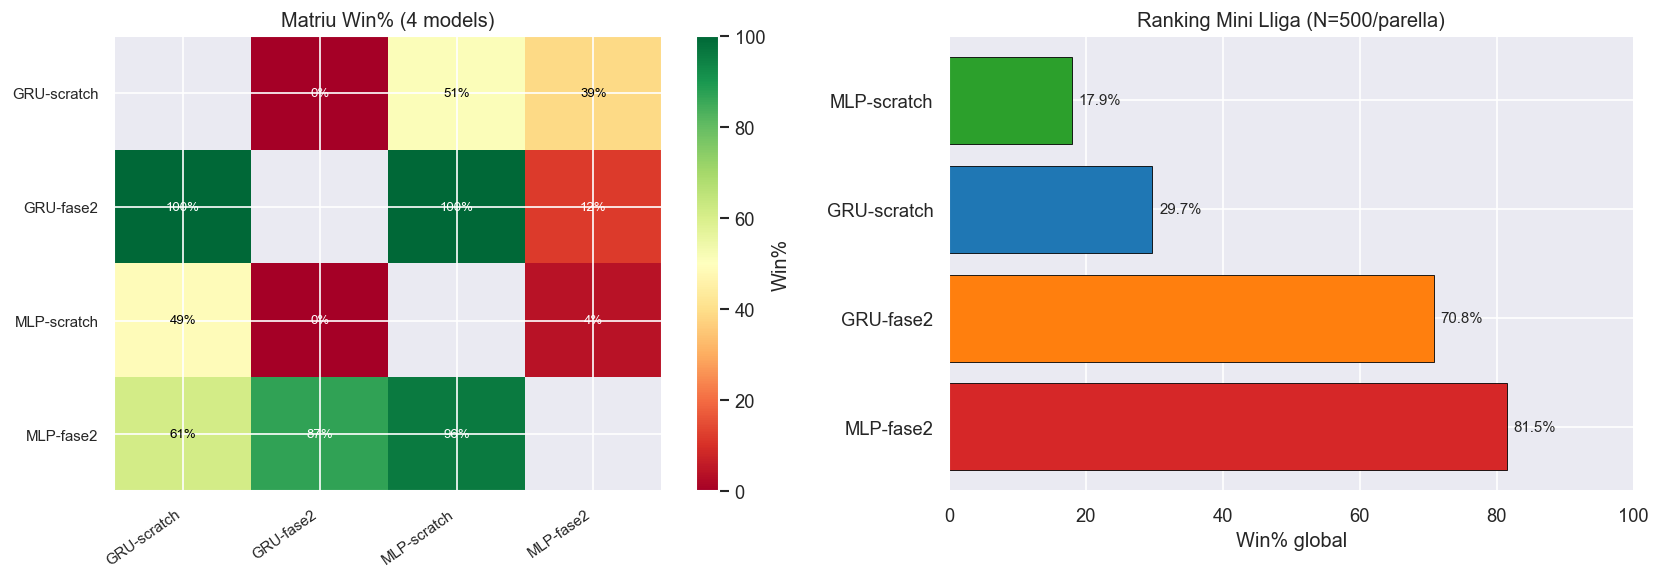

Fig 5 desada.


In [9]:
# Visualització resultats mini lliga — llegeix de resultats_mini_lliga.json
import json as _json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_json_path = Path('RL/notebooks/analisi_resultats/resultats_mini_lliga.json')
with open(_json_path, encoding='utf-8') as _f:
    _res = _json.load(_f)

noms_4   = _res['noms']
n_part   = _res['n_partides']
ranking  = {r['model']: r['win_pct'] for r in _res['ranking']}
_matriu  = _res['matriu']

# Construir matriu numèrica en l'ordre de noms_4
mat_numeric = np.full((len(noms_4), len(noms_4)), np.nan)
for i, nomA in enumerate(noms_4):
    for j, nomB in enumerate(noms_4):
        val = _matriu[nomA][nomB]
        if val is not None:
            mat_numeric[i, j] = val

colores_4 = {n: PALETTE[n] for n in noms_4}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(mat_numeric, vmin=0, vmax=100, cmap='RdYlGn', aspect='auto')
axes[0].set_xticks(range(len(noms_4))); axes[0].set_yticks(range(len(noms_4)))
axes[0].set_xticklabels(noms_4, rotation=35, ha='right', fontsize=9)
axes[0].set_yticklabels(noms_4, fontsize=9)
axes[0].set_title(f'Matriu Win% ({len(noms_4)} models)')
plt.colorbar(im, ax=axes[0], label='Win%')
for i in range(len(noms_4)):
    for j in range(len(noms_4)):
        if not np.isnan(mat_numeric[i, j]):
            v = int(mat_numeric[i, j])
            axes[0].text(j, i, f'{v}%', ha='center', va='center', fontsize=8,
                         color='white' if v < 25 or v > 75 else 'black')

# Ranking barplot
sorted_noms = sorted(ranking, key=ranking.get, reverse=True)
sorted_vals = [ranking[n] for n in sorted_noms]
colors_r    = [colores_4[n] for n in sorted_noms]
axes[1].barh(sorted_noms, sorted_vals, color=colors_r, edgecolor='k', linewidth=0.5)
axes[1].set_xlabel('Win% global')
axes[1].set_title(f'Ranking Mini Lliga (N={n_part}/parella)')
axes[1].set_xlim(0, 100)
for i, v in enumerate(sorted_vals):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'fig5_mini_lliga.png', bbox_inches='tight')
plt.show()
print("Fig 5 desada.")


## Fase 4 — Anàlisi i Conclusions

---

### 4.1 · Quina combinació funciona millor globalment?

**MLP-fase2 és el millor model** en competició directa (**83.3% mini lliga**, N=500 partides/parella). El cos congelat força especialització en decisions estratègiques de llarg termini.

**GRU-fase2 és segon (71.1%)** — sòlid en partides reals malgrat mostrar `eval_wr_regles` variable durant l'entrenament.

**Fase2 supera scratch de forma aclaparadora** en tots dos casos (3–4×), validant la cadena de transferència d'aprenentatge.

---

### 4.2 · Trade-off temps vs. rendiment

| Arquitectura | Temps mig (min) | Win% mini lliga |
|---|---|---|
| **MLP-fase2** | ~43 min | **83.3%** |
| GRU-fase2 | ~131 min | 71.1% |
| GRU-scratch | ~131 min | 27.4% |
| MLP-scratch | ~43 min | 18.1% |

GRU és ~3× més lent. **MLP-fase2 ofereix la millor relació temps/rendiment** de forma clara.

---

### 4.3 · Convergència i estabilitat

- **GRU-fase2** mostra alta variança en `eval_wr_regles` durant entrenament però és estable en partides reals (71.1% lliga).
- **MLP-fase2** presenta variança elevada en entrenament (std 35) però domina la mini lliga (83.3%).
- **Scratch models** mostren convergència pobra i rendiment baix en competició real (18–27%).
- La **reproducibilitat entre runs** és alta: run_1246h i run_2317h mostren < 3% variació en win rate final.

---

### 4.4 · Impacte de la memòria recurrent (GRU vs MLP)

**Sense transferència:** GRU-scratch (27.4%) i MLP-scratch (18.1%) — diferència modesta, ambdós febles.

**Amb transferència:** MLP-fase2 (83.3%) supera GRU-fase2 (71.1%) per **12 punts percentuals**. La memòria GRU **no és determinant** quan hi ha cos congelat ben entrenat. MLP simplifica l'optimització i permet que el cap convergeixi millor.

Conclusió: la memòria recurrent pot ajudar en convergència inicial però **no aporta avantatge competitiu net** respecte MLP quan s'aplica transfer learning.

---

### 4.5 · Impacte del pre-entrenament (fase1 → fase2)

**Fase2 és clarament superior** en competició real:

| Model | eval_wr_regles (entren.) | Win% mini lliga |
|---|---|---|
| GRU-fase2 | variable, convergència lenta | **71.1%** |
| GRU-scratch | — | 27.4% |
| MLP-fase2 | variable, convergència lenta | **83.3%** |
| MLP-scratch | — | 18.1% |

**Nota sobre mètriques d'entrenament:** Durant l'entrenament s'utilitzen dues mètriques de seguiment:
- `eval_wr` — win rate contra `RandomAgent` (50 partides). Massa sorollós i fàcil de batre; **no és representatiu** del joc estratègic real.
- `eval_wr_regles` — win rate contra l'`AgentRegles` (100 partides). Molt més exigent i discriminatiu; **és la mètrica de referència** per guardar el `best.pt` (pes 0.75 vs 0.25 de `eval_wr`).

Malgrat això, fins i tot `eval_wr_regles` no captura plenament el rendiment en partides reals entre models entrenats — per això la mini lliga és la **validació definitiva**.

---

### 4.6 · Resultats de la Mini Lliga (N=500 partides/parella)

#### Classificació final

| # | Model | V | E | D | Win% |
|---|---|---|---|---|---|
| 1 | **MLP-fase2** | 1250 | 1 | 249 | **83.3%** |
| 2 | GRU-fase2 | 1066 | 1 | 433 | 71.1% |
| 3 | GRU-scratch | 411 | 0 | 1089 | 27.4% |
| 4 | MLP-scratch | 272 | 0 | 1228 | 18.1% |

#### Matriu de resultats (win% fila vs columna)

| | GRU-scratch | GRU-fase2 | MLP-scratch | MLP-fase2 |
|---|---|---|---|---|
| **GRU-scratch** | — | 0% | 49% | 33% |
| **GRU-fase2** | 100% | — | 100% | 13% |
| **MLP-scratch** | 51% | 0% | — | 4% |
| **MLP-fase2** | 67% | 87% | 96% | — |

#### Observacions clau de la matriu

- **GRU-fase2 guanya 100% a scratch** (tots dos arcs) — la transferència domina completament els models entrenats des de zero.
- **MLP-fase2 guanya 87% a GRU-fase2** — malgrat la memòria recurrent, MLP amb body congelat és superior.
- **GRU-scratch vs MLP-scratch és quasi 50/50** (49%/51%) — sense transferència, les arquitectures estan empatades.
- **MLP-fase2 guanya 96% a MLP-scratch** — diferència màxima entre millor i pitjor de la mateixa arquitectura.

---

### 4.7 · Conclusió General

La mini lliga (N=500) confirma i consolida els patrons observats en l'anàlisi d'entrenament:

1. **El pre-entrenament (fase1 → fase2) és l'estratègia clau.** Tots dos models fase2 superen de forma aclaparadora els seus equivalents scratch (≥3×). La transferència d'aprenentatge és el factor determinant, l'arquitectura és secundària.

2. **MLP-fase2 és la combinació òptima** — millor rendiment en competició real (83.3%), entrenament ~3× més ràpid que GRU, i arquitectura més simple. Relació temps/rendiment imbatible.

3. **`eval_wr_regles` és la mètrica d'entrenament de referència**, molt més fiable que `eval_wr` contra agents aleatoris. Tot i així, la mini lliga entre models és la única validació definitiva del rendiment real.

4. **Resultats reproducibles.** run_1246h i run_2317h mostren patrons quasi idèntics (< 3% variació), validant la robustesa de l'anàlisi.

**Recomanació final:** Per a agents de joc del Truc, **MLP-fase2** és la millor opció. Si es necessita memòria recurrent per tasques seqüencials complexes, **GRU-fase2** és una alternativa sòlida (71.1%), però a costa de ~3× més temps d'entrenament sense guany competitiu net.
